# Predicting Wine quality using AdaBoost Classifier

### Importing Libraries and Loading data

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('winequality-red.csv',sep=';')

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df['target'] = df.quality.apply(lambda x: 1 if x>=7 else 0)

In [6]:
print("Before SMOTE:\n",df.target.value_counts())

Before SMOTE:
 target
0    1382
1     217
Name: count, dtype: int64


In [7]:
x = df.drop(['quality','target'],axis=1)
y = df['target']

In [8]:
smote = SMOTE(random_state=42)
x_balanced,y_balanced = smote.fit_resample(x,y)

In [9]:
print("After SMOTE:\n",y_balanced.value_counts())

After SMOTE:
 target
0    1382
1    1382
Name: count, dtype: int64


In [10]:
x_train,x_test,y_train,y_test = train_test_split(
    x_balanced,y_balanced,random_state=42,test_size=0.2,stratify=y_balanced
)

In [14]:
base_estimator = DecisionTreeClassifier(max_depth=1)

In [17]:
ada_model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

In [18]:
ada_model.fit(x_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [19]:
y_pred = ada_model.predict(x_test)

In [20]:
print("Classification Report:\n",classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       277
           1       0.85      0.84      0.84       276

    accuracy                           0.85       553
   macro avg       0.85      0.85      0.85       553
weighted avg       0.85      0.85      0.85       553



In [21]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.8462929475587704


Confusion Matrix


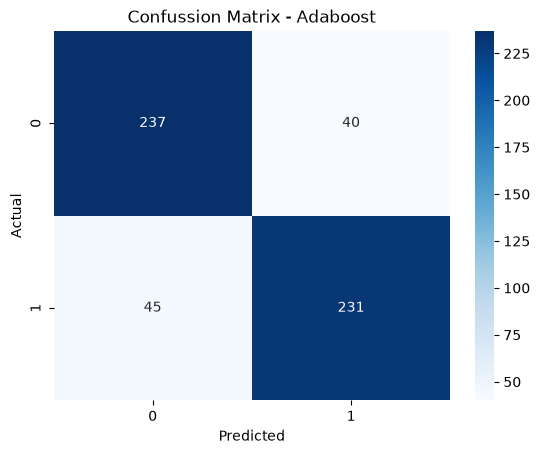

In [23]:
print("Confusion Matrix")
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confussion Matrix - Adaboost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()